## GPT 3.5



Hallucination Type occurs before Final Step
Schema-Based: Attribute Overanalysis 165
Schema-Based: Value Misrepresentation 87
Logic-Based: Clause Abuse 258
Logic-Based: Mathematical Delusion 100
Schema-Based: Schema Contradiction 93
Logic-Based: Join Redundancy 42


Hallucination Type occurs in Final Step
Schema-Based: Value Misrepresentation 132
Logic-Based: Mathematical Delusion 101
Logic-Based: Clause Abuse 123
Schema-Based: Schema Contradiction 97
Schema-Based: Attribute Overanalysis 117
Logic-Based: Join Redundancy 55


Hallucination Type occurs in Both
Schema-Based: Value Misrepresentation 46
Logic-Based: Mathematical Delusion 63
Logic-Based: Clause Abuse 66
Schema-Based: Attribute Overanalysis 65
Logic-Based: Join Redundancy 18
Schema-Based: Schema Contradiction 54


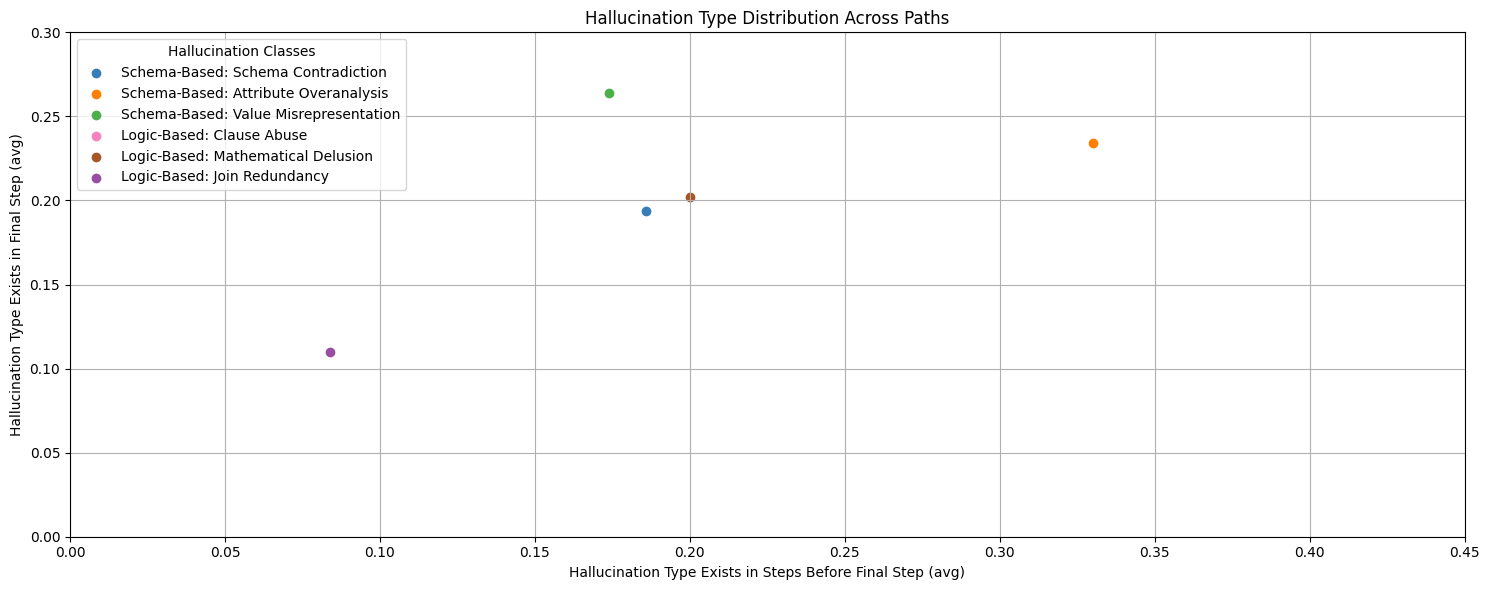

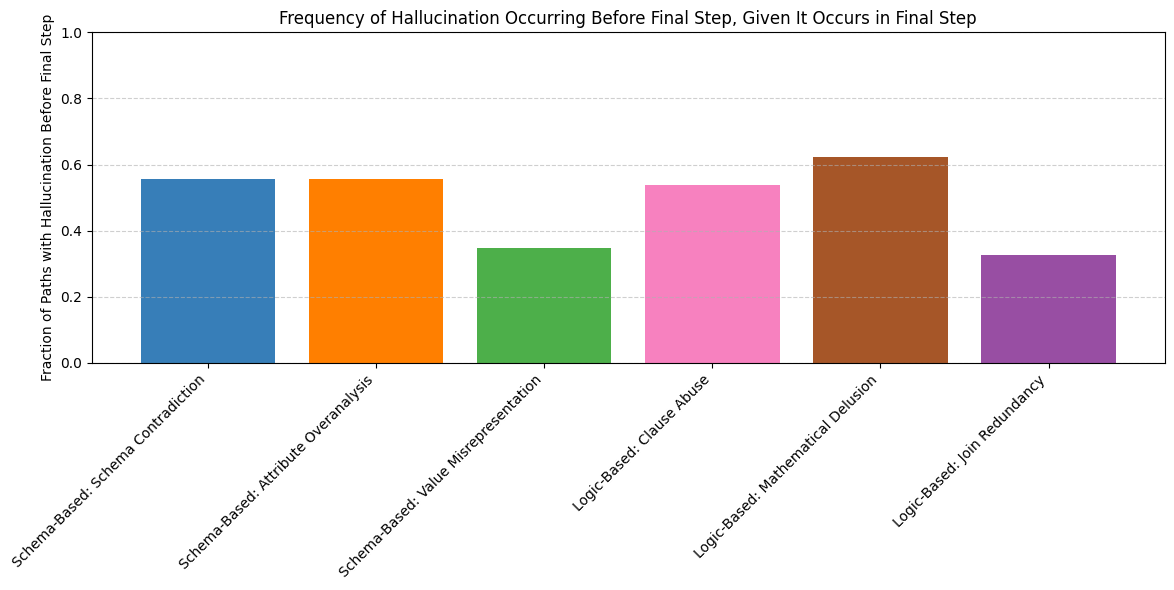

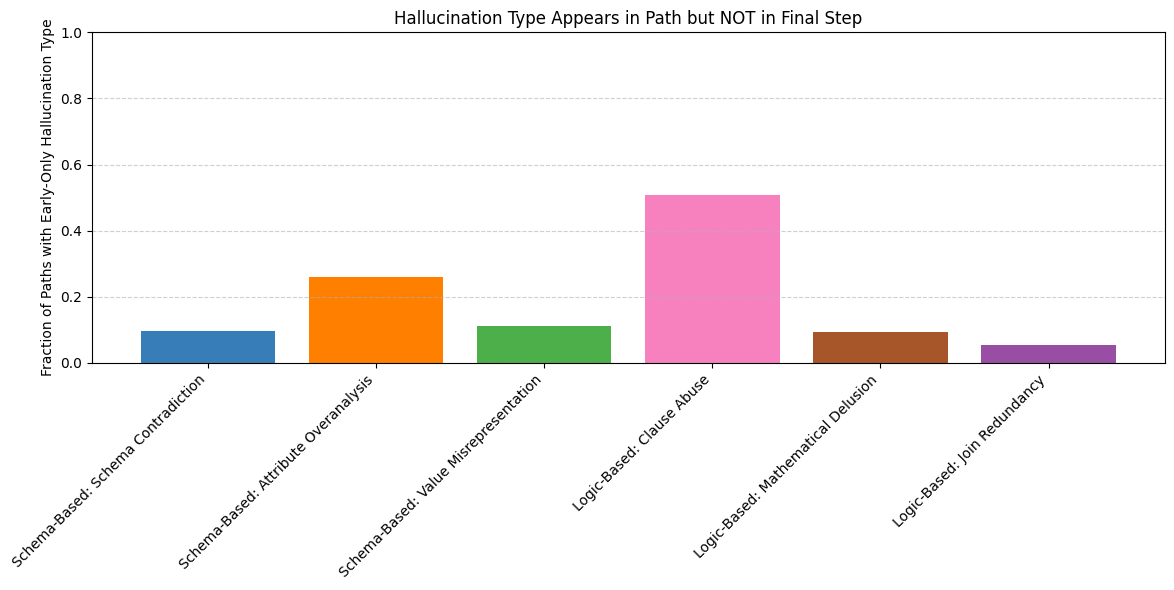

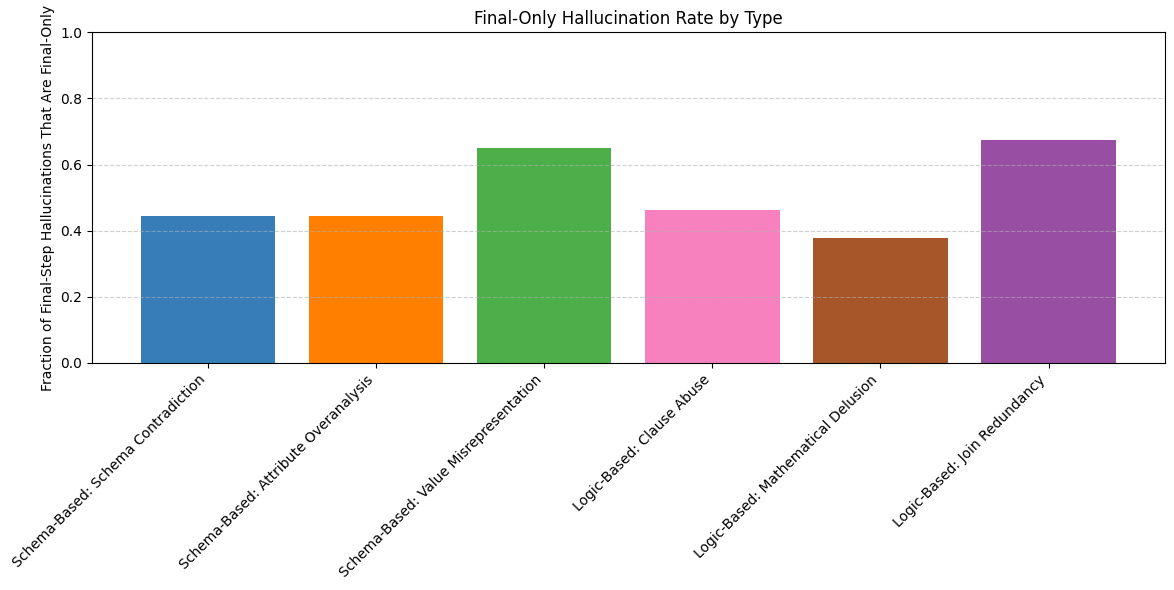

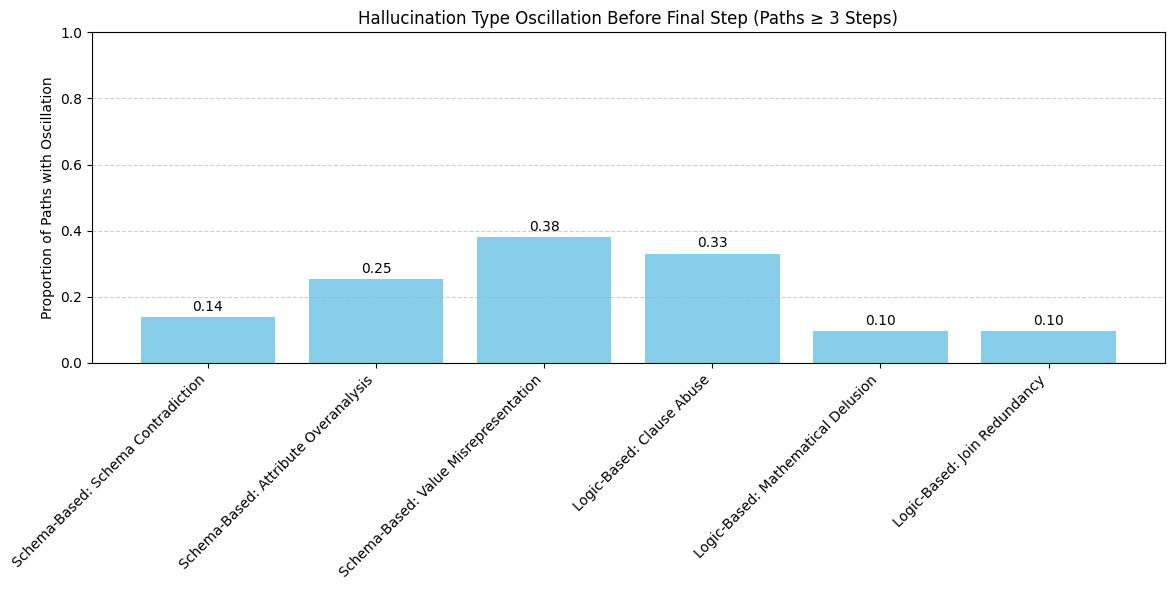

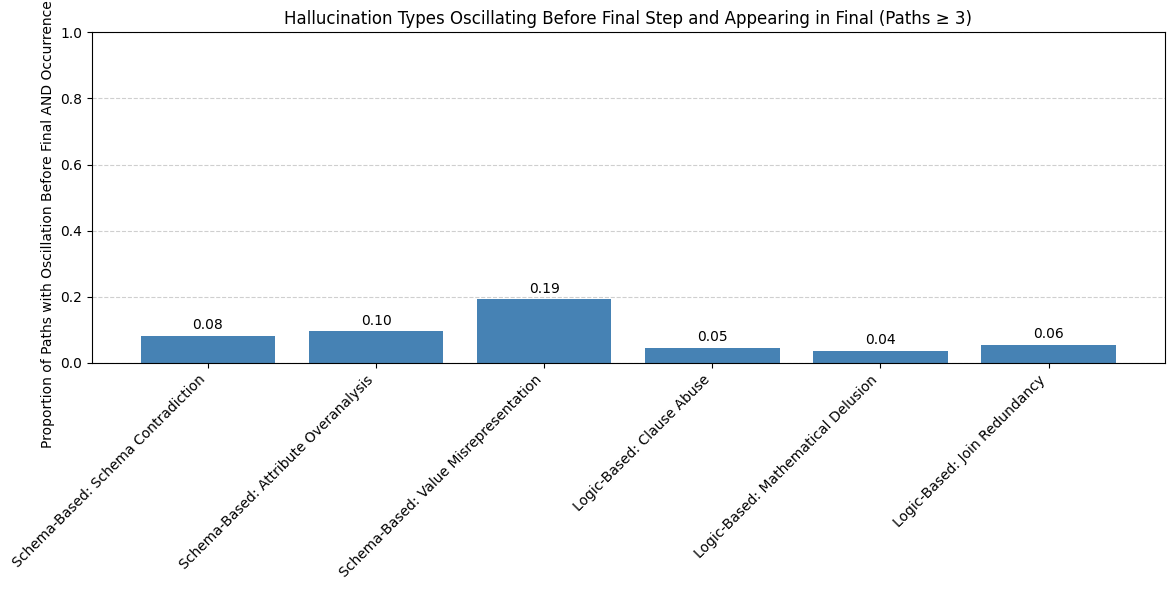

In [4]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_3_5.json', 'r') as f:
    data = json.load(f)

# Define the hallucination categories and their colors
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3','#999999', '#e41a1c', '#dede00']

color_map = dict(zip(hallucination_types, colors))

# Initialize counters
before_final_counts = defaultdict(int)
final_step_counts = defaultdict(int)
before_and_final_step_counts = defaultdict(int)
total_entries = 0

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue
    total_entries += 1

    found_before_final = {ht: False for ht in hallucination_types}
    found_in_final = {ht: False for ht in hallucination_types}
    found_in_both = {ht: False for ht in hallucination_types}

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}

        for htype in hallucination_types:
            if htype in types_in_step:
                if i == len(path) - 1:
                    found_in_final[htype] = True
                else:
                    found_before_final[htype] = True

            if found_in_final[htype] == True and found_before_final[htype] == True:
                found_in_both[htype] = True
                    
    for htype in hallucination_types:
        if found_before_final[htype]:
            before_final_counts[htype] += 1
        if found_in_final[htype]:
            final_step_counts[htype] += 1
        if found_in_both[htype]:
            before_and_final_step_counts[htype] += 1

# Prepare and plot
plt.figure(figsize=(15, 6))
for htype in hallucination_types:
    x = before_final_counts[htype] / total_entries
    y = final_step_counts[htype] / total_entries
    plt.scatter(x, y, color=color_map[htype], label=htype)




print("\n")
print("Hallucination Type occurs before Final Step")
for ht in before_final_counts:
    print(ht, before_final_counts[ht])

print("\n")
print("Hallucination Type occurs in Final Step")
for ht in final_step_counts:
    print(ht, final_step_counts[ht])

print("\n")
print("Hallucination Type occurs in Both")
for ht in before_and_final_step_counts:
    print(ht, before_and_final_step_counts[ht])

plt.xlabel("Hallucination Type Exists in Steps Before Final Step (avg)")
plt.ylabel("Hallucination Type Exists in Final Step (avg)")
plt.ylim(0.0, 0.3)
plt.xlim(0.0, 0.45)
plt.title("Hallucination Type Distribution Across Paths")
plt.grid(True)
plt.legend(loc="upper left", title="Hallucination Classes")
plt.tight_layout()
plt.show()


# -------------------------------Frequency of Hallucination Occurring Before Final Step, Given It Occurs in Final Step-------------------#


from collections import defaultdict

paths_with_final_htype = defaultdict(int)
paths_with_htype_before_final = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {h[0] for h in path[-1].get("hallucination", []) if isinstance(h, list) and h}
    if not final_step_hallucs:
        continue

    # For each hallucination type in final step
    for htype in final_step_hallucs:
        paths_with_final_htype[htype] += 1

        # Check if it also appears before final step (any step)
        found_before = any(
            htype in {h[0] for h in step.get("hallucination", []) if isinstance(h, list) and h}
            for step in path[:-1]
        )
        if found_before:
            paths_with_htype_before_final[htype] += 1

# Calculate fractions per hallucination type (default 0 if no paths)
fractions = {
    htype: (paths_with_htype_before_final[htype] / paths_with_final_htype[htype])
    if paths_with_final_htype[htype] > 0 else 0
    for htype in hallucination_types
}

# Plotting
import matplotlib.pyplot as plt

x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar(x, y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Paths with Hallucination Before Final Step")
plt.title("Frequency of Hallucination Occurring Before Final Step, Given It Occurs in Final Step")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


# ------------------------------Hallucination Occurring Before Final Step but NOT in Final Step-------------------#



from collections import defaultdict
import matplotlib.pyplot as plt

paths_with_type_not_final = defaultdict(int)
paths_with_type_before_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {h[0] for h in path[-1].get("hallucination", []) if isinstance(h, list) and h}
    all_prior_steps = path[:-1]

    # Get all hallucination types in earlier steps
    halluc_in_prior = set()
    for step in all_prior_steps:
        halluc_in_prior.update(
            h[0] for h in step.get("hallucination", []) if isinstance(h, list) and h
        )

    for htype in hallucination_types:
        # We're only interested in paths where htype is not in the final step
        if htype not in final_step_hallucs:
            paths_with_type_not_final[htype] += 1
            if htype in halluc_in_prior:
                paths_with_type_before_only[htype] += 1

# Calculate fractions per hallucination type
fractions = {
    htype: (paths_with_type_before_only[htype] / paths_with_type_not_final[htype])
    if paths_with_type_not_final[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar(x, y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Paths with Early-Only Hallucination Type")
plt.title("Hallucination Type Appears in Path but NOT in Final Step")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


# -------------------------------Hallucination does NOT Occur Before Final Step, but It DOES Occurs in Final Step-------------------#



from collections import defaultdict
import matplotlib.pyplot as plt

# You already have this defined:
# hallucination_types = [...]
# color_map = dict(zip(hallucination_types, colors))

# Track per hallucination type:
# - Total paths where it appears in final step
# - Of those, how many paths do NOT contain it earlier
paths_with_final = defaultdict(int)
paths_with_final_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {h[0] for h in path[-1].get("hallucination", []) if isinstance(h, list) and h}
    prior_hallucs = set()
    for step in path[:-1]:
        prior_hallucs.update(h[0] for h in step.get("hallucination", []) if isinstance(h, list) and h)

    for htype in hallucination_types:
        if htype in final_step_hallucs:
            paths_with_final[htype] += 1
            if htype not in prior_hallucs:
                paths_with_final_only[htype] += 1

# Compute fractions
fractions = {
    htype: (paths_with_final_only[htype] / paths_with_final[htype])
    if paths_with_final[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
x = hallucination_types
y = [fractions[htype] for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar(x, y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Final-Step Hallucinations That Are Final-Only")
plt.title("Final-Only Hallucination Rate by Type")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load JSON
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_3_5.json', 'r') as f:
    data = json.load(f)

# Define hallucination types
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

# Count oscillations and total eligible paths
oscillation_counts = defaultdict(int)
eligible_paths = 0

for entry in data:
    path = entry.get("path", [])
    if len(path) < 3:
        continue

    eligible_paths += 1
    presence = {htype: [] for htype in hallucination_types}

    for step in path[:-1]:  # Before final step
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}
        for htype in hallucination_types:
            presence[htype].append(htype in types_in_step)

    for htype in hallucination_types:
        pres_list = presence[htype]
        if any(pres_list) and not all(pres_list):
            oscillation_counts[htype] += 1

# Prepare data for bar graph
x_labels = hallucination_types
y_values = [oscillation_counts[ht] / eligible_paths for ht in hallucination_types]

# Plot bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(x_labels, y_values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of Paths with Oscillation")
plt.title("Hallucination Type Oscillation Before Final Step (Paths ≥ 3 Steps)")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()



import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load JSON
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_3_5.json', 'r') as f:
    data = json.load(f)

# Define hallucination types
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

# Count oscillations (before final) + presence in final step
oscillation_counts = defaultdict(int)
eligible_paths = 0

for entry in data:
    path = entry.get("path", [])
    if len(path) < 3:
        continue

    eligible_paths += 1
    presence = {htype: [] for htype in hallucination_types}

    for step in path[:-1]:  # Only before final step
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}
        for htype in hallucination_types:
            presence[htype].append(htype in types_in_step)

    final_step = path[-1]
    final_hallucinations = final_step.get("hallucination", [])
    final_types = {h[0] for h in final_hallucinations if isinstance(h, list) and h}

    for htype in hallucination_types:
        pres_list = presence[htype]
        if any(pres_list) and not all(pres_list) and htype in final_types:
            oscillation_counts[htype] += 1

# Prepare data for bar graph
x_labels = hallucination_types
y_values = [oscillation_counts[ht] / eligible_paths for ht in hallucination_types]

# Plot bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(x_labels, y_values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of Paths with Oscillation Before Final AND Occurrence in Final")
plt.title("Hallucination Types Oscillating Before Final Step and Appearing in Final (Paths ≥ 3)")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()



## GPT 4.0

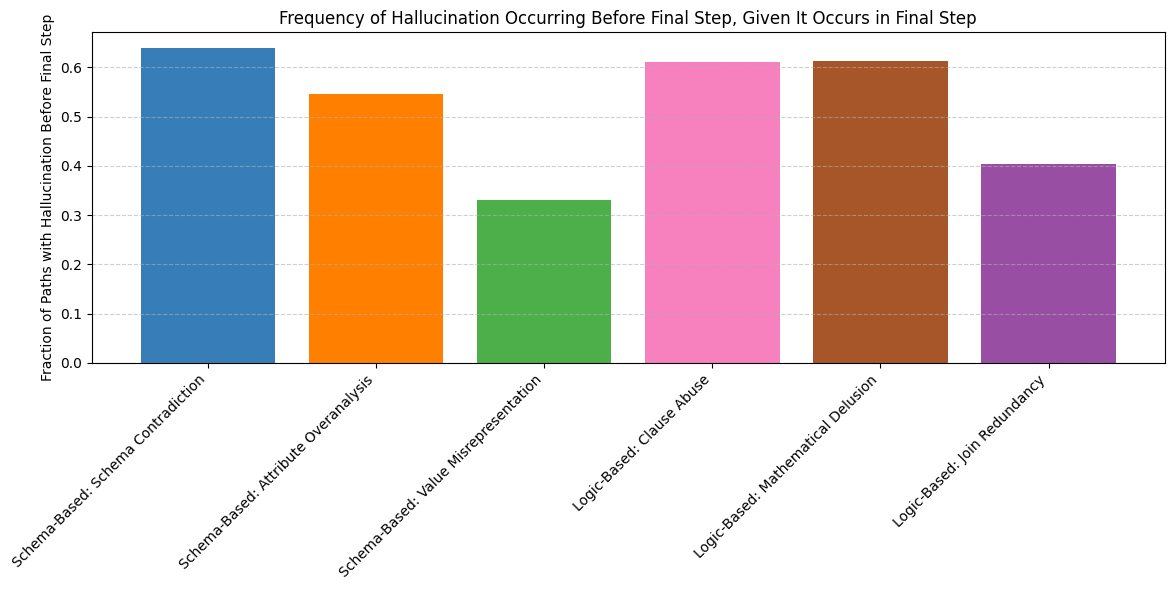

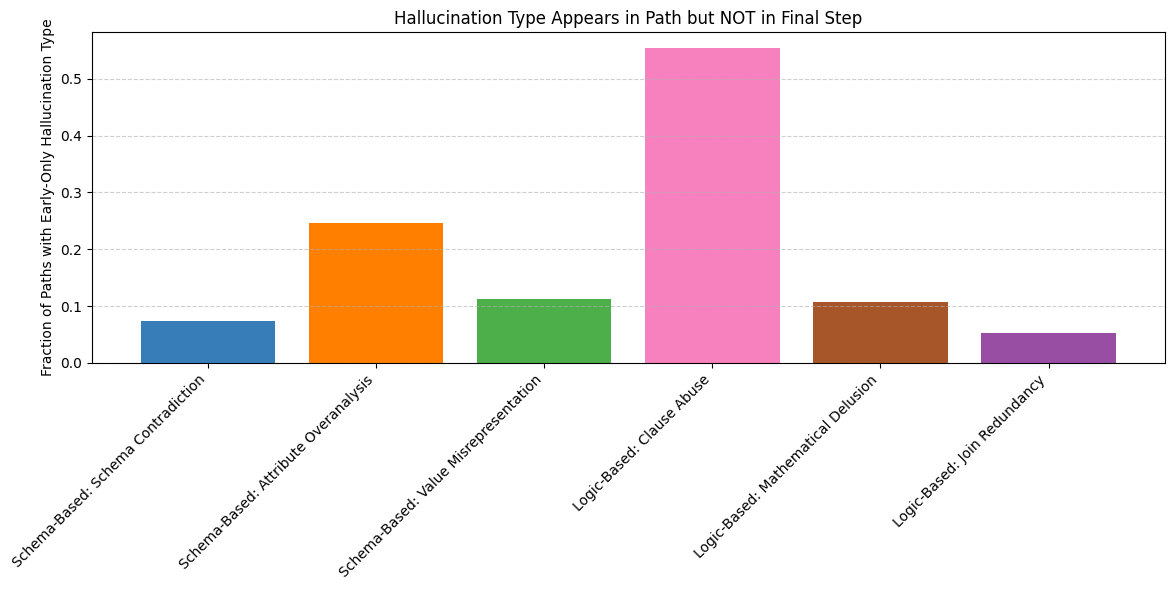

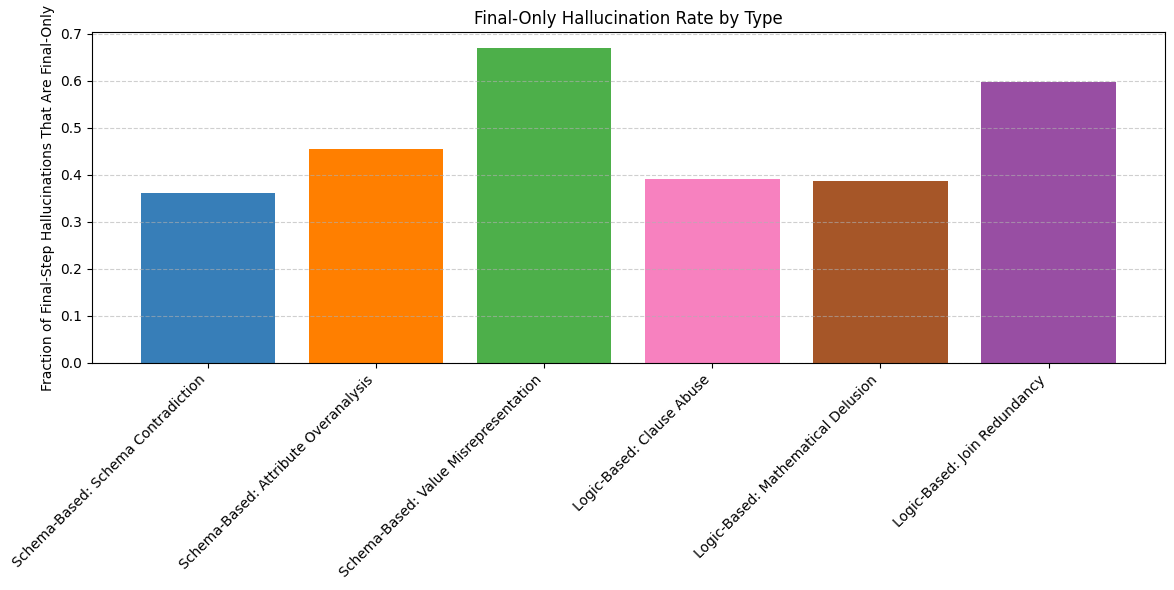

In [7]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

# Define the hallucination categories and their colors
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3','#999999', '#e41a1c', '#dede00']

color_map = dict(zip(hallucination_types, colors))


# -------------------------------Frequency of Hallucination Occurring Before Final Step, Given It Occurs in Final Step-------------------#


from collections import defaultdict

paths_with_final_htype = defaultdict(int)
paths_with_htype_before_final = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {h[0] for h in path[-1].get("hallucination", []) if isinstance(h, list) and h}
    if not final_step_hallucs:
        continue

    # For each hallucination type in final step
    for htype in final_step_hallucs:
        paths_with_final_htype[htype] += 1

        # Check if it also appears before final step (any step)
        found_before = any(
            htype in {h[0] for h in step.get("hallucination", []) if isinstance(h, list) and h}
            for step in path[:-1]
        )
        if found_before:
            paths_with_htype_before_final[htype] += 1

# Calculate fractions per hallucination type (default 0 if no paths)
fractions = {
    htype: (paths_with_htype_before_final[htype] / paths_with_final_htype[htype])
    if paths_with_final_htype[htype] > 0 else 0
    for htype in hallucination_types
}

# Plotting
import matplotlib.pyplot as plt

x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar(x, y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Paths with Hallucination Before Final Step")
plt.title("Frequency of Hallucination Occurring Before Final Step, Given It Occurs in Final Step")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ------------------------------Hallucination Occurring Before Final Step but NOT in Final Step-------------------#



from collections import defaultdict
import matplotlib.pyplot as plt

paths_with_type_not_final = defaultdict(int)
paths_with_type_before_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {h[0] for h in path[-1].get("hallucination", []) if isinstance(h, list) and h}
    all_prior_steps = path[:-1]

    # Get all hallucination types in earlier steps
    halluc_in_prior = set()
    for step in all_prior_steps:
        halluc_in_prior.update(
            h[0] for h in step.get("hallucination", []) if isinstance(h, list) and h
        )

    for htype in hallucination_types:
        # We're only interested in paths where htype is not in the final step
        if htype not in final_step_hallucs:
            paths_with_type_not_final[htype] += 1
            if htype in halluc_in_prior:
                paths_with_type_before_only[htype] += 1

# Calculate fractions per hallucination type
fractions = {
    htype: (paths_with_type_before_only[htype] / paths_with_type_not_final[htype])
    if paths_with_type_not_final[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar(x, y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Paths with Early-Only Hallucination Type")
plt.title("Hallucination Type Appears in Path but NOT in Final Step")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# -------------------------------Hallucination does NOT Occur Before Final Step, but It DOES Occurs in Final Step-------------------#



from collections import defaultdict
import matplotlib.pyplot as plt

# You already have this defined:
# hallucination_types = [...]
# color_map = dict(zip(hallucination_types, colors))

# Track per hallucination type:
# - Total paths where it appears in final step
# - Of those, how many paths do NOT contain it earlier
paths_with_final = defaultdict(int)
paths_with_final_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {h[0] for h in path[-1].get("hallucination", []) if isinstance(h, list) and h}
    prior_hallucs = set()
    for step in path[:-1]:
        prior_hallucs.update(h[0] for h in step.get("hallucination", []) if isinstance(h, list) and h)

    for htype in hallucination_types:
        if htype in final_step_hallucs:
            paths_with_final[htype] += 1
            if htype not in prior_hallucs:
                paths_with_final_only[htype] += 1

# Compute fractions
fractions = {
    htype: (paths_with_final_only[htype] / paths_with_final[htype])
    if paths_with_final[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
x = hallucination_types
y = [fractions[htype] for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar(x, y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Final-Step Hallucinations That Are Final-Only")
plt.title("Final-Only Hallucination Rate by Type")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()





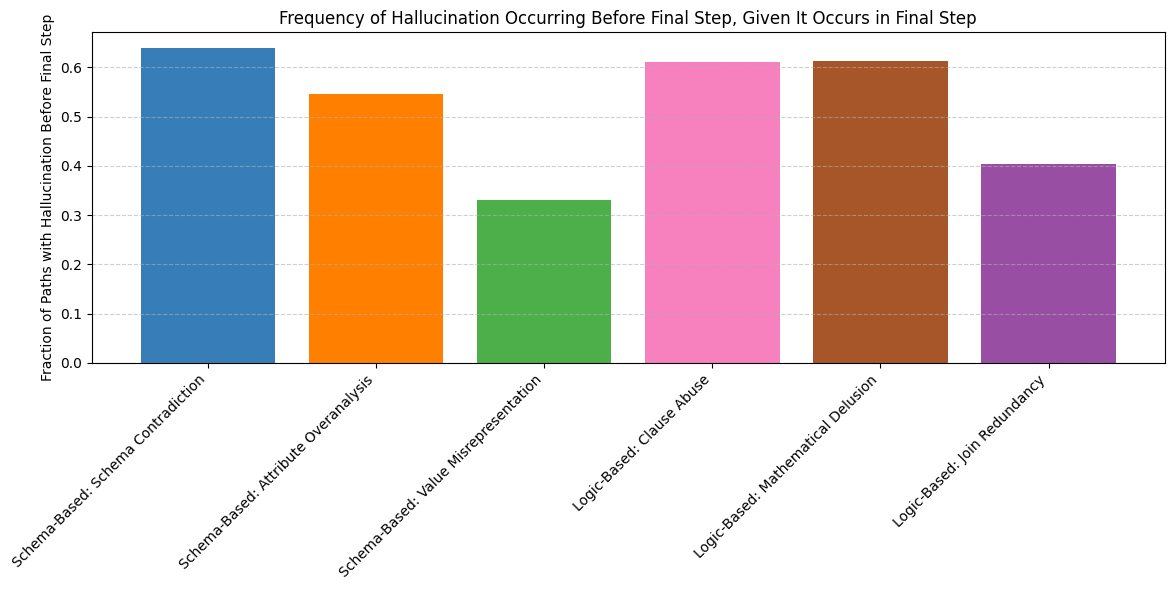

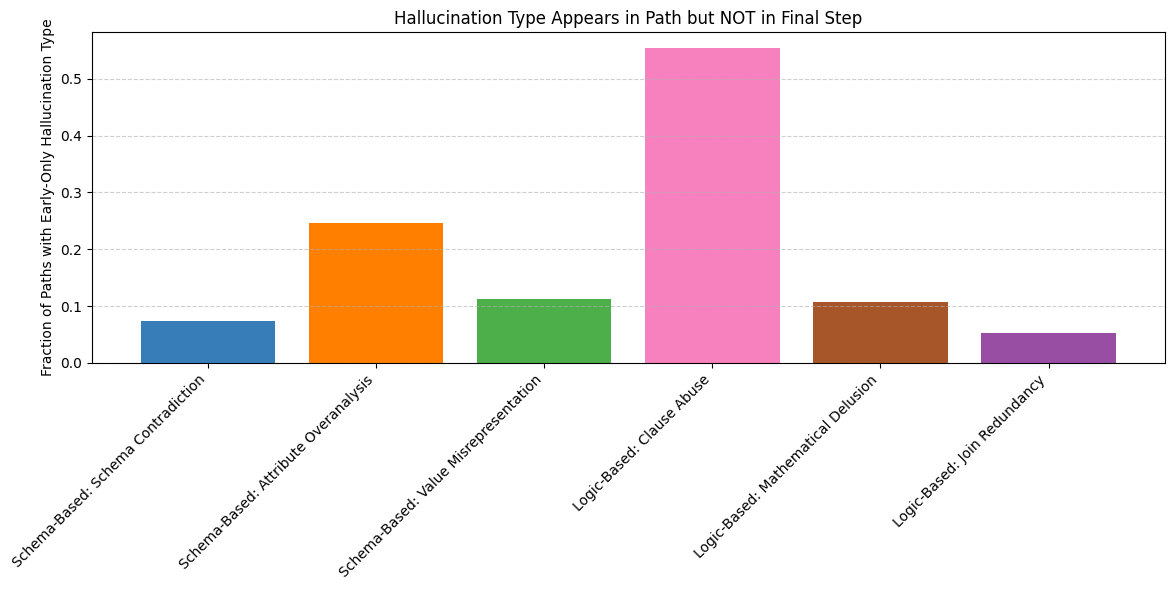

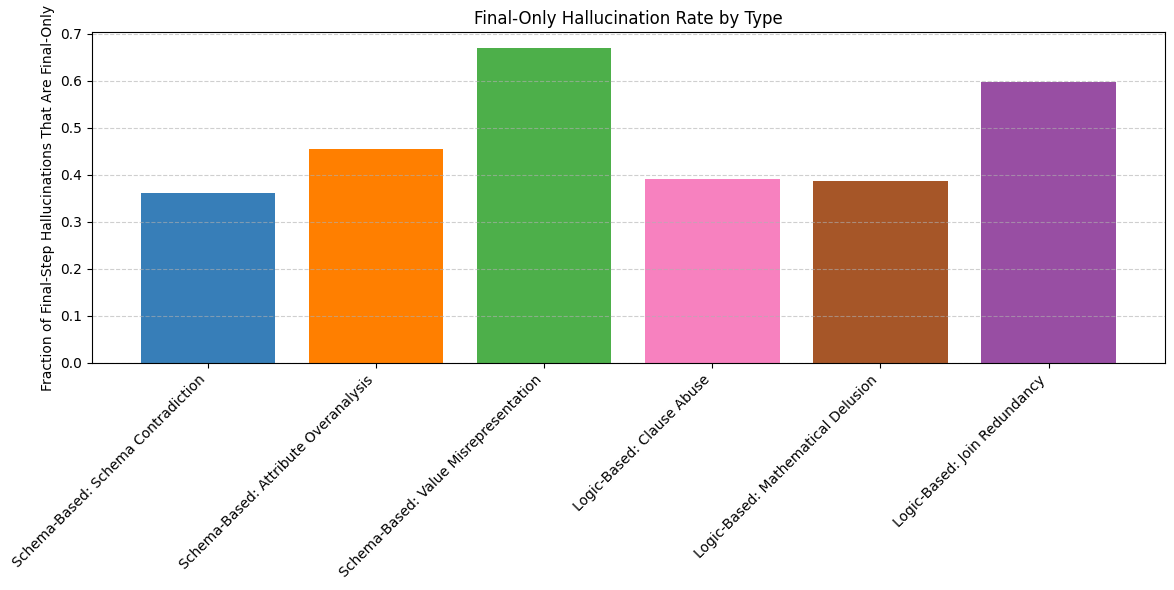

In [12]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

# Define normalized hallucination categories (as tuples)
hallucination_types = [
    ("Schema-Based", "Schema Contradiction"),
    ("Schema-Based", "Attribute Overanalysis"),
    ("Schema-Based", "Value Misrepresentation"),
    ("Logic-Based", "Clause Abuse"),
    ("Logic-Based", "Mathematical Delusion"),
    ("Logic-Based", "Join Redundancy")
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))


# -------------------------------1. Frequency Before Final Step-------------------#

paths_with_final_htype = defaultdict(int)
paths_with_htype_before_final = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {
        tuple(h[0].split(": ", 1)) for h in path[-1].get("hallucination", [])
        if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
    }
    if not final_step_hallucs:
        continue

    for htype in final_step_hallucs:
        paths_with_final_htype[htype] += 1

        found_before = any(
            htype in {
                tuple(h[0].split(": ", 1)) for h in step.get("hallucination", [])
                if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
            }
            for step in path[:-1]
        )
        if found_before:
            paths_with_htype_before_final[htype] += 1

fractions = {
    htype: (paths_with_htype_before_final[htype] / paths_with_final_htype[htype])
    if paths_with_final_htype[htype] > 0 else 0
    for htype in hallucination_types
}

x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar([f"{a}: {b}" for a, b in x], y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Paths with Hallucination Before Final Step")
plt.title("Frequency of Hallucination Occurring Before Final Step, Given It Occurs in Final Step")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ------------------------------2. Hallucination Before Final Only-------------------#

paths_with_type_not_final = defaultdict(int)
paths_with_type_before_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {
        tuple(h[0].split(": ", 1)) for h in path[-1].get("hallucination", [])
        if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
    }

    halluc_in_prior = set()
    for step in path[:-1]:
        halluc_in_prior.update(
            tuple(h[0].split(": ", 1)) for h in step.get("hallucination", [])
            if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
        )

    for htype in hallucination_types:
        if htype not in final_step_hallucs:
            paths_with_type_not_final[htype] += 1
            if htype in halluc_in_prior:
                paths_with_type_before_only[htype] += 1

fractions = {
    htype: (paths_with_type_before_only[htype] / paths_with_type_not_final[htype])
    if paths_with_type_not_final[htype] > 0 else 0
    for htype in hallucination_types
}

x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar([f"{a}: {b}" for a, b in x], y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Paths with Early-Only Hallucination Type")
plt.title("Hallucination Type Appears in Path but NOT in Final Step")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# -------------------------------3. Final-Only Hallucination Rate-------------------#

paths_with_final = defaultdict(int)
paths_with_final_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {
        tuple(h[0].split(": ", 1)) for h in path[-1].get("hallucination", [])
        if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
    }

    prior_hallucs = set()
    for step in path[:-1]:
        prior_hallucs.update(
            tuple(h[0].split(": ", 1)) for h in step.get("hallucination", [])
            if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
        )

    for htype in hallucination_types:
        if htype in final_step_hallucs:
            paths_with_final[htype] += 1
            if htype not in prior_hallucs:
                paths_with_final_only[htype] += 1

fractions = {
    htype: (paths_with_final_only[htype] / paths_with_final[htype])
    if paths_with_final[htype] > 0 else 0
    for htype in hallucination_types
}

x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar([f"{a}: {b}" for a, b in x], y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Final-Step Hallucinations That Are Final-Only")
plt.title("Final-Only Hallucination Rate by Type")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


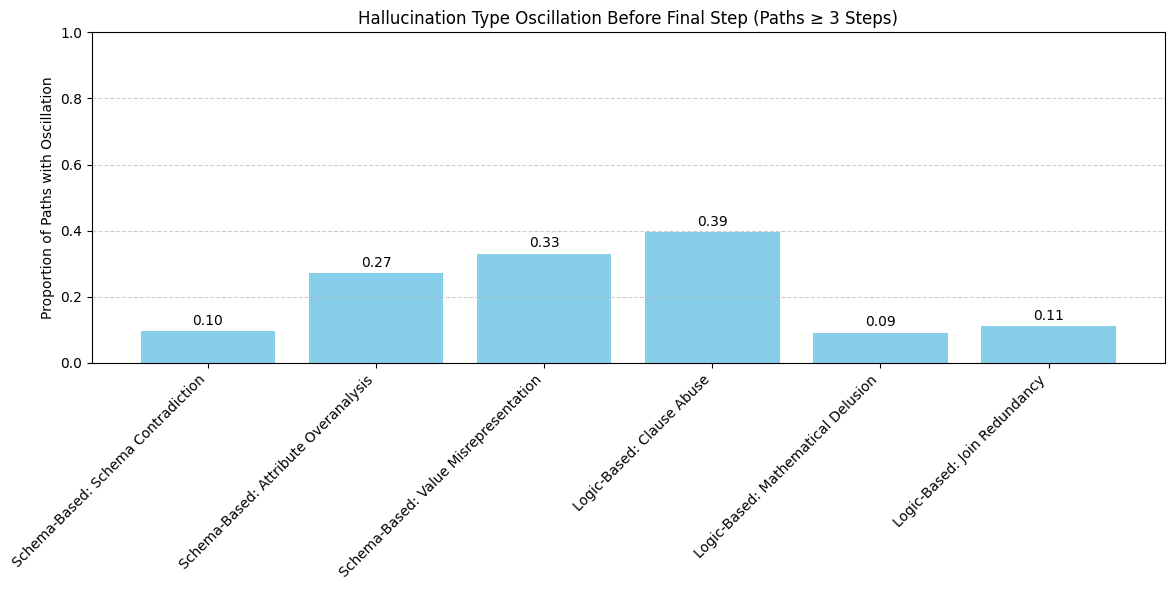

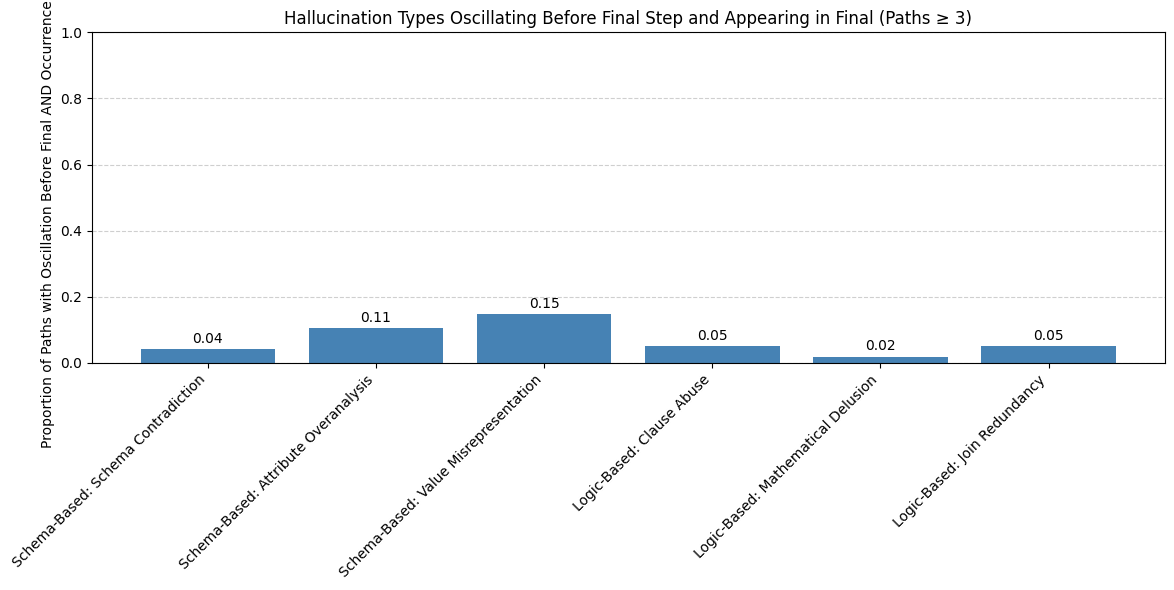

In [10]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load JSON
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

# Define hallucination types
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

# Count oscillations and total eligible paths
oscillation_counts = defaultdict(int)
eligible_paths = 0

for entry in data:
    path = entry.get("path", [])
    if len(path) < 3:
        continue

    eligible_paths += 1
    presence = {htype: [] for htype in hallucination_types}

    for step in path[:-1]:  # Before final step
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}
        for htype in hallucination_types:
            presence[htype].append(htype in types_in_step)

    for htype in hallucination_types:
        pres_list = presence[htype]
        if any(pres_list) and not all(pres_list):
            oscillation_counts[htype] += 1

# Prepare data for bar graph
x_labels = hallucination_types
y_values = [oscillation_counts[ht] / eligible_paths for ht in hallucination_types]

# Plot bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(x_labels, y_values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of Paths with Oscillation")
plt.title("Hallucination Type Oscillation Before Final Step (Paths ≥ 3 Steps)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()



import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load JSON
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

# Define hallucination types
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

# Count oscillations (before final) + presence in final step
oscillation_counts = defaultdict(int)
eligible_paths = 0

for entry in data:
    path = entry.get("path", [])
    if len(path) < 3:
        continue

    eligible_paths += 1
    presence = {htype: [] for htype in hallucination_types}

    for step in path[:-1]:  # Only before final step
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}
        for htype in hallucination_types:
            presence[htype].append(htype in types_in_step)

    final_step = path[-1]
    final_hallucinations = final_step.get("hallucination", [])
    final_types = {h[0] for h in final_hallucinations if isinstance(h, list) and h}

    for htype in hallucination_types:
        pres_list = presence[htype]
        if any(pres_list) and not all(pres_list) and htype in final_types:
            oscillation_counts[htype] += 1

# Prepare data for bar graph
x_labels = hallucination_types
y_values = [oscillation_counts[ht] / eligible_paths for ht in hallucination_types]

# Plot bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(x_labels, y_values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of Paths with Oscillation Before Final AND Occurrence in Final")
plt.title("Hallucination Types Oscillating Before Final Step and Appearing in Final (Paths ≥ 3)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


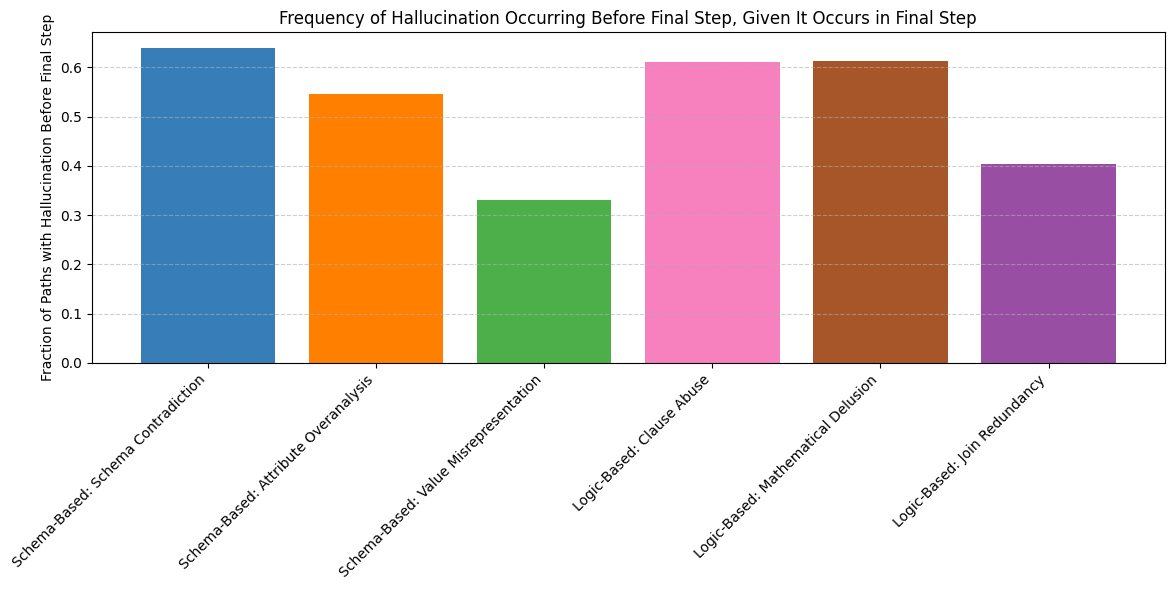

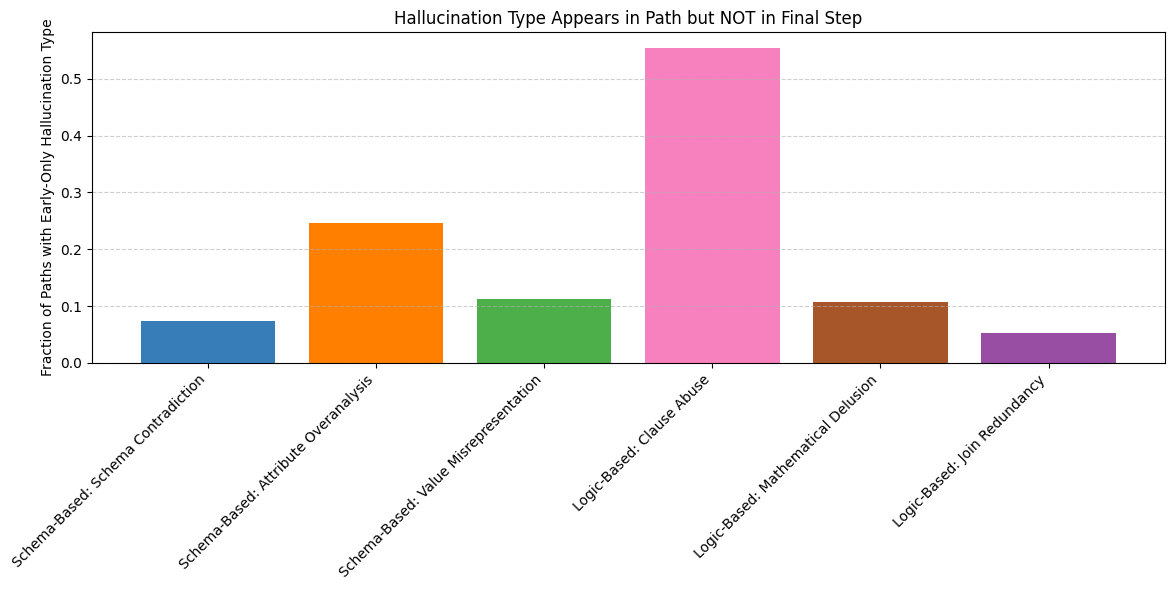

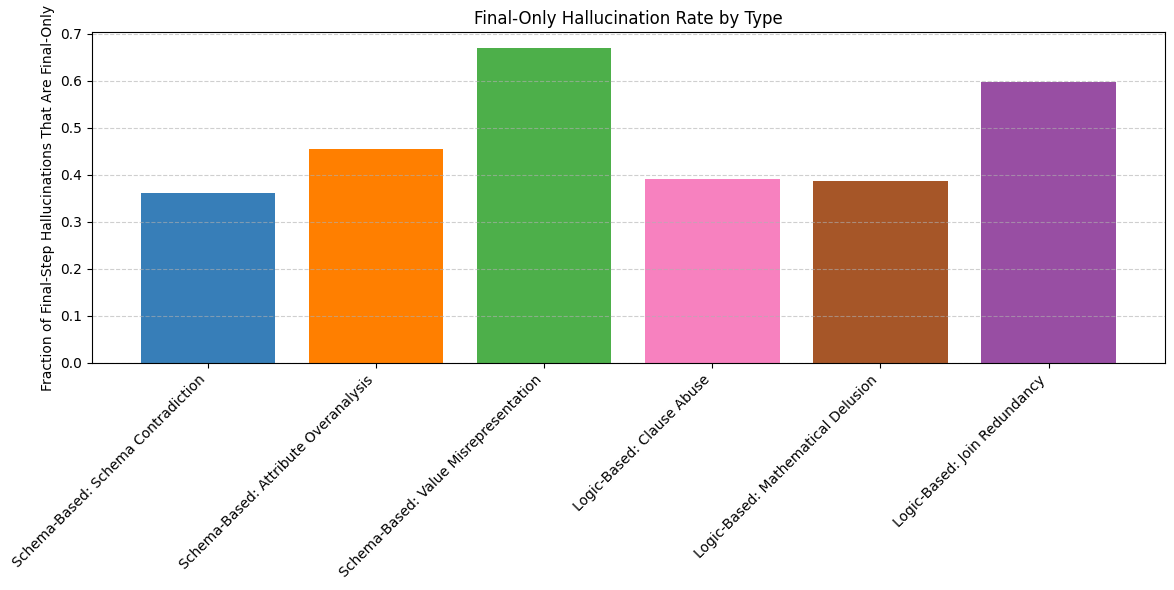

In [13]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

# Define normalized hallucination categories (as tuples)
hallucination_types = [
    ("Schema-Based", "Schema Contradiction"),
    ("Schema-Based", "Attribute Overanalysis"),
    ("Schema-Based", "Value Misrepresentation"),
    ("Logic-Based", "Clause Abuse"),
    ("Logic-Based", "Mathematical Delusion"),
    ("Logic-Based", "Join Redundancy")
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))


# -------------------------------1. Frequency Before Final Step-------------------#

paths_with_final_htype = defaultdict(int)
paths_with_htype_before_final = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {
        tuple(h[0].split(": ", 1)) for h in path[-1].get("hallucination", [])
        if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
    }
    if not final_step_hallucs:
        continue

    for htype in final_step_hallucs:
        paths_with_final_htype[htype] += 1

        found_before = any(
            htype in {
                tuple(h[0].split(": ", 1)) for h in step.get("hallucination", [])
                if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
            }
            for step in path[:-1]
        )
        if found_before:
            paths_with_htype_before_final[htype] += 1

fractions = {
    htype: (paths_with_htype_before_final[htype] / paths_with_final_htype[htype])
    if paths_with_final_htype[htype] > 0 else 0
    for htype in hallucination_types
}

x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar([f"{a}: {b}" for a, b in x], y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Paths with Hallucination Before Final Step")
plt.title("Frequency of Hallucination Occurring Before Final Step, Given It Occurs in Final Step")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ------------------------------2. Hallucination Before Final Only-------------------#

paths_with_type_not_final = defaultdict(int)
paths_with_type_before_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {
        tuple(h[0].split(": ", 1)) for h in path[-1].get("hallucination", [])
        if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
    }

    halluc_in_prior = set()
    for step in path[:-1]:
        halluc_in_prior.update(
            tuple(h[0].split(": ", 1)) for h in step.get("hallucination", [])
            if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
        )

    for htype in hallucination_types:
        if htype not in final_step_hallucs:
            paths_with_type_not_final[htype] += 1
            if htype in halluc_in_prior:
                paths_with_type_before_only[htype] += 1

fractions = {
    htype: (paths_with_type_before_only[htype] / paths_with_type_not_final[htype])
    if paths_with_type_not_final[htype] > 0 else 0
    for htype in hallucination_types
}

x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar([f"{a}: {b}" for a, b in x], y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Paths with Early-Only Hallucination Type")
plt.title("Hallucination Type Appears in Path but NOT in Final Step")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# -------------------------------3. Final-Only Hallucination Rate-------------------#

paths_with_final = defaultdict(int)
paths_with_final_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    final_step_hallucs = {
        tuple(h[0].split(": ", 1)) for h in path[-1].get("hallucination", [])
        if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
    }

    prior_hallucs = set()
    for step in path[:-1]:
        prior_hallucs.update(
            tuple(h[0].split(": ", 1)) for h in step.get("hallucination", [])
            if isinstance(h, list) and len(h) >= 1 and ": " in h[0]
        )

    for htype in hallucination_types:
        if htype in final_step_hallucs:
            paths_with_final[htype] += 1
            if htype not in prior_hallucs:
                paths_with_final_only[htype] += 1

fractions = {
    htype: (paths_with_final_only[htype] / paths_with_final[htype])
    if paths_with_final[htype] > 0 else 0
    for htype in hallucination_types
}

x = hallucination_types
y = [fractions.get(htype, 0) for htype in x]

plt.figure(figsize=(12, 6))
bars = plt.bar([f"{a}: {b}" for a, b in x], y, color=[color_map.get(htype, "gray") for htype in x])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraction of Final-Step Hallucinations That Are Final-Only")
plt.title("Final-Only Hallucination Rate by Type")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


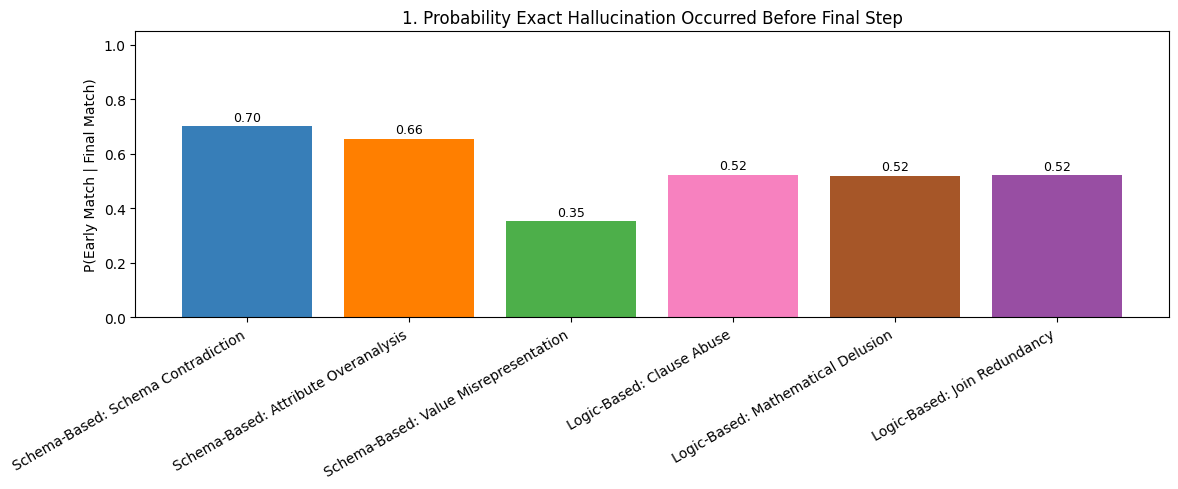

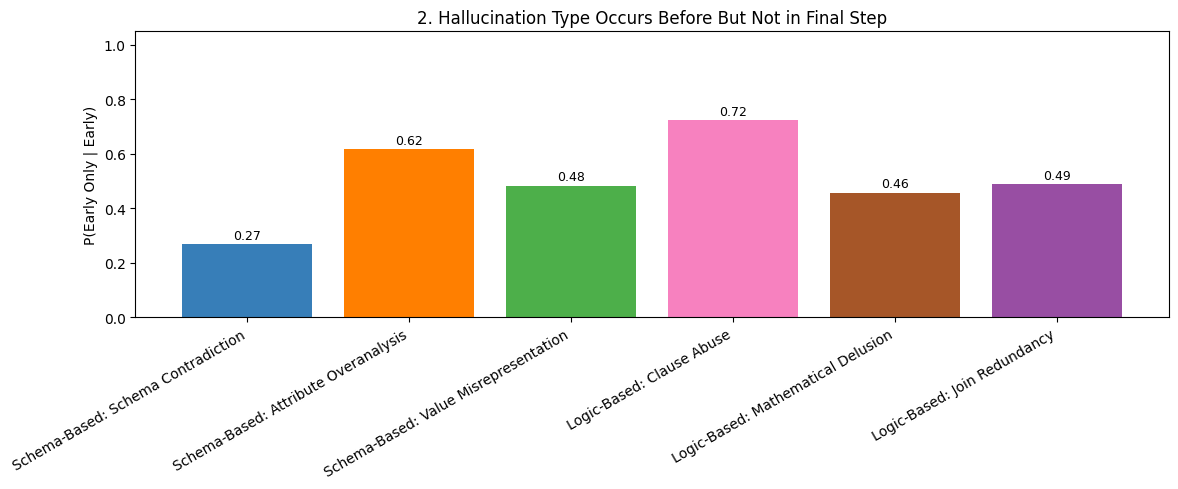

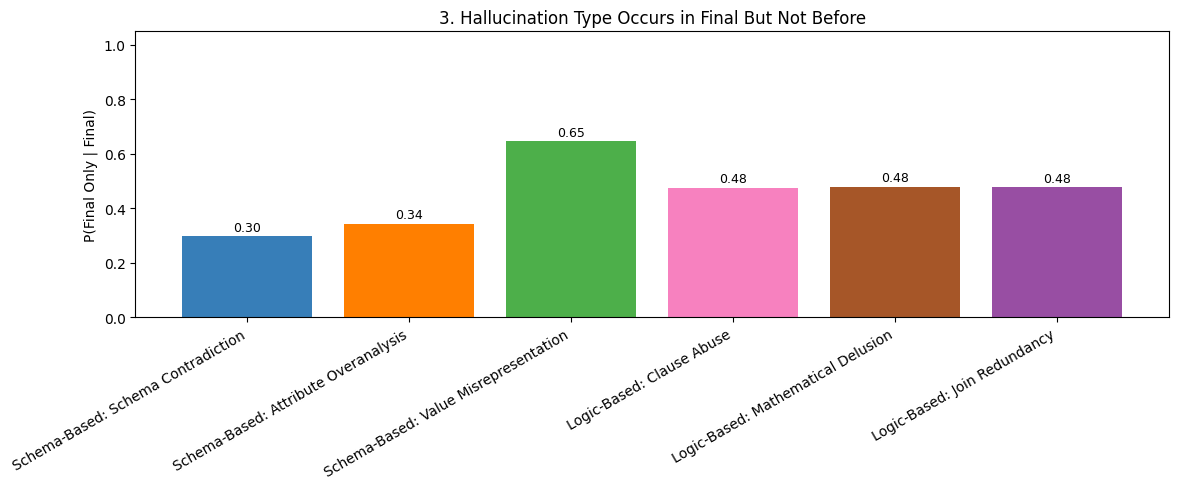

In [15]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load JSON
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0_history.json', 'r') as f:
    data = json.load(f)

# Define top-level hallucination types (grouped by h[0])
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

# -------------------- 1. P(Occurred Before | Occurred in Final) --------------------

paths_with_final_htype = defaultdict(int)
paths_with_htype_before_final = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                htype = h[0]
                final_step_halls_by_type[htype].add(h)
        else:
            for h in halluc_set:
                htype = h[0]
                all_prev_halls_by_type[htype].add(h)

    for htype in hallucination_types:
        prev_set = all_prev_halls_by_type[htype]
        final_set = final_step_halls_by_type[htype]

        if final_set:
            paths_with_final_htype[htype] += 1
            if prev_set & final_set:
                paths_with_htype_before_final[htype] += 1

fractions_1 = {
    htype: paths_with_htype_before_final[htype] / paths_with_final_htype[htype]
    if paths_with_final_htype[htype] > 0 else 0
    for htype in hallucination_types
}

plt.figure(figsize=(12, 5))
bars = plt.bar(
    fractions_1.keys(),
    fractions_1.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Early Match | Final Match)")
plt.title("1. Probability Exact Hallucination Occurred Before Final Step")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# -------------------- 2. P(Early But Not Final) --------------------

paths_with_type_not_final = defaultdict(int)
paths_with_type_before_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                final_step_halls_by_type[h[0]].add(h)
        else:
            for h in halluc_set:
                all_prev_halls_by_type[h[0]].add(h)

    for htype in hallucination_types:
        prev = all_prev_halls_by_type[htype]
        final = final_step_halls_by_type[htype]

        if prev and not (prev & final):
            paths_with_type_before_only[htype] += 1
        if prev:
            paths_with_type_not_final[htype] += 1

fractions_2 = {
    htype: paths_with_type_before_only[htype] / paths_with_type_not_final[htype]
    if paths_with_type_not_final[htype] > 0 else 0
    for htype in hallucination_types
}

plt.figure(figsize=(12, 5))
bars = plt.bar(
    fractions_2.keys(),
    fractions_2.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Early Only | Early)")
plt.title("2. Hallucination Type Occurs Before But Not in Final Step")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# -------------------- 3. P(Final Only | Final) --------------------

paths_with_final = defaultdict(int)
paths_with_final_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                final_step_halls_by_type[h[0]].add(h)
        else:
            for h in halluc_set:
                all_prev_halls_by_type[h[0]].add(h)

    for htype in hallucination_types:
        final = final_step_halls_by_type[htype]
        prev = all_prev_halls_by_type[htype]

        if final:
            paths_with_final[htype] += 1
            if not (final & prev):
                paths_with_final_only[htype] += 1

fractions_3 = {
    htype: paths_with_final_only[htype] / paths_with_final[htype]
    if paths_with_final[htype] > 0 else 0
    for htype in hallucination_types
}

plt.figure(figsize=(12, 5))
bars = plt.bar(
    fractions_3.keys(),
    fractions_3.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Final Only | Final)")
plt.title("3. Hallucination Type Occurs in Final But Not Before")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()
